In [1]:
import sys
import os
sys.path.append(os.path.abspath(".."))

import torch
import matplotlib.pyplot as plt
import numpy as np

from src.datasets.factory import build_dataloaders
from src.models.factory import build_model
from src.training.trainer import Trainer
from src.training.losses import build_loss
from src.training.optimizers import build_optimizer
from src.utils.seed import set_seed

set_seed(42)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

Device: cuda


In [2]:
config = {
    "data_root": os.path.abspath("..")+"/data/raw/ModelNet10_views",
    "splits_file": os.path.abspath("..")+"/data/processed/splits.json",
    "batch_size": 64,
    "epochs": 10,  # shorter for debugging
    "model": "model_s",
    "optimizer": "adamw",
    "loss": "ce",
    "augmentation": False,
}

In [3]:
train_loader, val_loader = build_dataloaders(
    config, augment=config["augmentation"]
)

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))

Train batches: 47
Val batches: 15


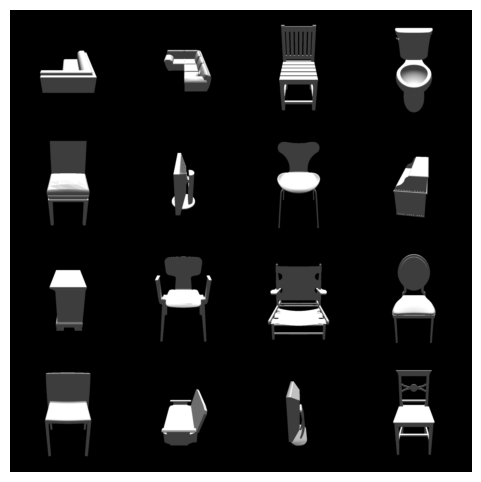

In [4]:
import torchvision

def show_batch(loader):
    imgs, labels = next(iter(loader))
    grid = torchvision.utils.make_grid(imgs[:16], nrow=4)
    plt.figure(figsize=(6,6))
    plt.imshow(grid.permute(1,2,0))
    plt.axis("off")

show_batch(train_loader)

In [5]:
model = build_model(config["model"]).to(device)

x, y = next(iter(train_loader))
x = x.to(device)

with torch.no_grad():
    out = model(x)

print("Output shape:", out.shape)

Output shape: torch.Size([64, 10])


In [6]:
model = build_model(config["model"]).to(device)
optimizer = build_optimizer(model, config)
loss_fn = build_loss(config["loss"])

x, y = next(iter(train_loader))
x, y = x.to(device), y.to(device)

for i in range(50):
    optimizer.zero_grad()
    out = model(x)
    loss = loss_fn(out, y)
    loss.backward()
    optimizer.step()

    if i % 10 == 0:
        preds = out.argmax(dim=1)
        acc = (preds == y).float().mean().item()
        print(f"Step {i} | Loss {loss.item():.4f} | Acc {acc:.4f}")

Step 0 | Loss 2.2956 | Acc 0.0312
Step 10 | Loss 1.1947 | Acc 0.6094
Step 20 | Loss 0.5476 | Acc 0.8125
Step 30 | Loss 0.3508 | Acc 0.8750
Step 40 | Loss 0.1618 | Acc 0.9531


In [7]:
model = build_model(config["model"]).to(device)
optimizer = build_optimizer(model, config)
loss_fn = build_loss(config["loss"])

train_accs = []
val_accs = []

def evaluate(loader):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            preds = out.argmax(dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)

    return correct / total

for epoch in range(10):
    model.train()
    correct = 0
    total = 0

    for x, y in train_loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        out = model(x)
        loss = loss_fn(out, y)
        loss.backward()
        optimizer.step()

        preds = out.argmax(dim=1)
        correct += (preds == y).sum().item()
        total += y.size(0)

    train_acc = correct / total
    val_acc = evaluate(val_loader)

    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(f"Epoch {epoch}: train={train_acc:.4f}, val={val_acc:.4f}")

Epoch 0: train=0.6526, val=0.3631
Epoch 1: train=0.8066, val=0.8711
Epoch 2: train=0.8474, val=0.8088
Epoch 3: train=0.8772, val=0.8915
Epoch 4: train=0.8959, val=0.9076
Epoch 5: train=0.9060, val=0.9237
Epoch 6: train=0.9137, val=0.9248
Epoch 7: train=0.9230, val=0.8303
Epoch 8: train=0.9217, val=0.9012
Epoch 9: train=0.9274, val=0.9130


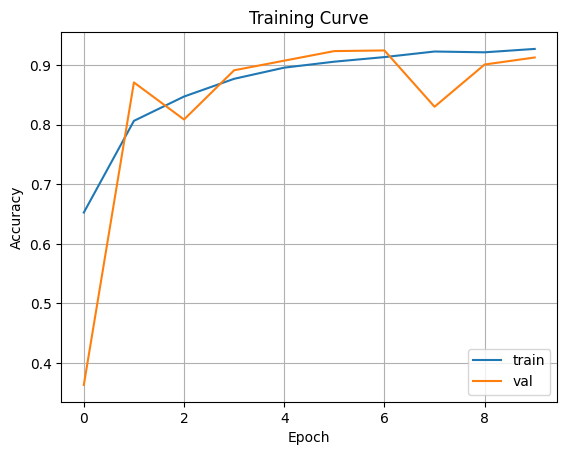

In [8]:
plt.plot(train_accs, label="train")
plt.plot(val_accs, label="val")
plt.legend()
plt.title("Training Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid()

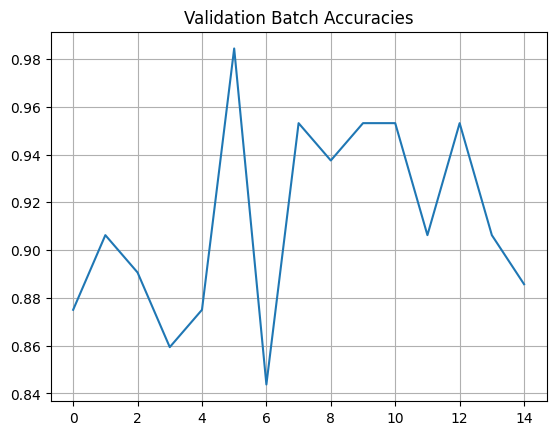

In [9]:
# Track per-batch validation accuracy to detect anomalies

def evaluate_detailed(loader):
    model.eval()
    batch_accs = []

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            preds = out.argmax(dim=1)
            acc = (preds == y).float().mean().item()
            batch_accs.append(acc)

    return batch_accs

batch_accs = evaluate_detailed(val_loader)

plt.plot(batch_accs)
plt.title("Validation Batch Accuracies")
plt.grid()